# Model-based and model-free control in the two-step task

> **Level** Advanced · **Time** 45 minutes · **Prerequisites** [Tutorial 1](../tutorials/first-model.ipynb) and [Tutorial 2](../tutorials/parameter-recovery.ipynb) ·
> **cpm components** [`HybridMBMF`](#cpm.applications.reinforcement_learning.HybridMBMF), [`SARSATrace`](#cpm.models.learning.SARSATrace), [`Simulator`](#cpm.generators.Simulator), [`FminBound`](#cpm.optimisation.FminBound) ·
> **Data** [`load_two_step_data`](#cpm.datasets.load_two_step_data), the adult data of Smid et al. (2022)

In this example, we use the hybrid model-based / model-free reinforcement learning model of Kool et al. (2016), in the 6-parameter variant used by Smid et al. (2022), which is available as [`HybridMBMF`](#cpm.applications.reinforcement_learning.HybridMBMF).

**What you'll learn**

- how to simulate purely model-free and purely model-based agents on the deterministic two-step task,
- the behavioural signature that tells the two apart (stay probabilities, Figure 4a in Smid et al., 2022),
- how well the parameters of the model can be recovered from simulated data,
- how to replicate the analyses of the adult data in Smid et al. (2022): the stay probabilities in Figure 4b, and the distributions of the fitted model parameters.

In [1]:
import cpm

print(cpm.__version__)

0.25.7.dev0


## The two-step task

On each trial, the agent is shown one of two **starting states**, $s_1 \in \{0, 1\}$, each with two actions (spaceships in the original task).
The chosen action deterministically leads to one of two **second-stage states**, $s_2$ (planets): action 0 always leads to planet 1, and action 1 always leads to planet 0, irrespective of the starting state.
Each planet pays out a reward between 0 and 9 points that drifts slowly over the course of the task.
The left/right screen position of the two actions is randomised on every trial.

Because the transitions are shared across starting states, a **model-based** agent that knows the transition structure can use what it learned about a planet in one starting state to choose in the other.
A **model-free** agent, in contrast, only learns the value of actions it has taken in each starting state, so a reward only affects its choices when the same starting state comes up again.

## The model

Let $Q_{MF}(s_1, a)$ be the model-free value of action $a$ in starting state $s_1$, and $Q_2(s_2)$ the value of planet $s_2$.
The model-based value of each action is computed from the transition matrix, $T$:

$$
Q_{MB}(a) = \sum_{s_2} T(a, s_2) Q_2(s_2)
$$

The two values are mixed with a weight $w$, and two stickiness terms are added: $M(s_1, a)$ is 1 if $a$ was chosen on the previous trial in the same starting state, and $R(a)$ is 1 if $a$ is displayed at the screen position of the previous response.

$$
Q_{hybrid}(s_1, a) = w Q_{MB}(a) + (1 - w) Q_{MF}(s_1, a) + \pi M(s_1, a) + \rho R(a)
$$

$$
P(a) = \frac{e^{\beta Q_{hybrid}(s_1, a)}}{\sum_{a'} e^{\beta Q_{hybrid}(s_1, a')}}
$$

After the choice, the values are updated with a SARSA rule with an eligibility trace ([`SARSATrace`](#cpm.models.learning.SARSATrace)):

$$
\delta_1 = Q_2(s_2) - Q_{MF}(s_1, a), \qquad \delta_2 = r - Q_2(s_2)
$$

$$
\Delta Q_{MF}(s_1, a) = \alpha \delta_1 + \lambda \alpha \delta_2, \qquad \Delta Q_2(s_2) = \alpha \delta_2
$$

This gives six free parameters:

| Parameter | Symbol | Description |
|---|---|---|
| `inv_temperature` | $\beta$ | Softmax inverse temperature |
| `learning_rate` | $\alpha$ | Learning rate |
| `eligibility_trace` | $\lambda$ | How much of the reward prediction error is carried back to the first stage |
| `mb_weight` | $w$ | Model-based weight: 0 is purely model-free, 1 is purely model-based |
| `choice_stickiness` | $\pi$ | Tendency to repeat the last action in the same starting state |
| `response_stickiness` | $\rho$ | Tendency to repeat the last screen position |

## Setting up the environment

First, we import the libraries we need.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

from cpm.applications.reinforcement_learning import HybridMBMF
from cpm.generators import Simulator
from cpm.optimisation import FminBound, minimise

## colours for the two conditions of the stay-probability plots
COLOR_SAME = "#2a78d6"  # same starting state
COLOR_DIFF = "#eb6834"  # different starting state

The model needs the following information on each trial when it generates choices:

- `s1`: the starting state,
- `stimuli_first`: which action is displayed on the left (0 or 1),
- `reward_0` and `reward_1`: what each planet would pay out on that trial.

The rewards follow a Gaussian random walk with a standard deviation of 2 points, bounded between 0 and 9 and rounded to whole points. The task has 140 trials, as in Smid et al. (2022).

In [3]:
def make_environment(n_participants, n_trials=140, sigma=2.0, seed=0):
    """Generate starting states, screen positions, and drifting rewards for each participant."""
    rng = np.random.default_rng(seed)
    environments = []
    for ppt in range(n_participants):
        rewards = np.zeros((n_trials, 2))
        rewards[0] = rng.uniform(3, 6, 2)  # start near the midpoint
        for t in range(1, n_trials):
            rewards[t] = np.clip(rewards[t - 1] + rng.normal(0, sigma, 2), 0, 9)
        environments.append(
            pd.DataFrame(
                {
                    "ppt": ppt,
                    "trial": np.arange(n_trials),
                    "s1": rng.integers(0, 2, n_trials),
                    "stimuli_first": rng.integers(0, 2, n_trials),
                    "reward_0": rewards[:, 0].round(),
                    "reward_1": rewards[:, 1].round(),
                }
            )
        )
    return pd.concat(environments, ignore_index=True)


environment = make_environment(n_participants=100, seed=2022)
environment.head(10)

,ppt,trial,s1,stimuli_first,reward_0,reward_1
0,0,0,1,1,4.0,3.0
1,0,1,0,0,8.0,0.0
2,0,2,1,0,9.0,0.0
3,0,3,0,1,4.0,0.0
4,0,4,0,0,5.0,0.0
5,0,5,0,0,2.0,0.0
6,0,6,0,1,3.0,3.0
7,0,7,1,1,1.0,3.0
8,0,8,1,1,2.0,5.0
9,0,9,1,1,0.0,2.0


## Simulating model-free and model-based agents

We create the model with `generate=True`, so that on each trial it samples an action from its policy instead of reading one from the data.
Because rewards are on a 0 to 9 scale, we initialise all values at the midpoint, `q_init=4.5`.
The table shows the free parameters, their bounds, and their (truncated normal) priors, which we will use later when fitting.

In [4]:
warnings.simplefilter("ignore")  # the environment has no 'observed' column yet
np.random.seed(2022)

model = HybridMBMF(
    data=environment[environment.ppt == 0],
    q_init=4.5,
    generate=True,
)
model.parameters.export()

,lower,upper,prior_fun,loc,scale,a,b
inv_temperature,0,5,<scipy.stats._distn_infrastructure.rv_continuo...,1.5,2.0,-0.75,1.75
learning_rate,0,1,<scipy.stats._distn_infrastructure.rv_continuo...,0.5,0.25,-2.0,2.0
eligibility_trace,0,1,<scipy.stats._distn_infrastructure.rv_continuo...,0.5,0.25,-2.0,2.0
mb_weight,0,1,<scipy.stats._distn_infrastructure.rv_continuo...,0.5,0.25,-2.0,2.0
choice_stickiness,-5,5,<scipy.stats._distn_infrastructure.rv_continuo...,0.0,1.0,-5.0,5.0
response_stickiness,-5,5,<scipy.stats._distn_infrastructure.rv_continuo...,0.0,1.0,-5.0,5.0


Half of the agents are purely model-free ($w = 0$) and half are purely model-based ($w = 1$); all other parameters are the same. We pass one set of parameters per participant to [`Simulator`](#cpm.generators.Simulator), as a `DataFrame` with one row per participant.

In [5]:
n_participants = environment.ppt.nunique()
group = np.where(np.arange(n_participants) < n_participants // 2, "model-free", "model-based")
agent_parameters = pd.DataFrame(
    {
        "inv_temperature": 1.0,
        "learning_rate": 0.5,
        "eligibility_trace": 0.5,
        "mb_weight": np.where(group == "model-free", 0.0, 1.0),
        "choice_stickiness": 0.0,
        "response_stickiness": 0.0,
    }
)

simulator = Simulator(
    wrapper=model,
    data=environment.groupby("ppt"),
    parameters=agent_parameters,
)
simulator.run()
simulated = simulator.export()
simulated[["ppt", "action", "s2", "reward", "position", "policy_0", "policy_1"]].head(10)

,ppt,action,s2,reward,position,policy_0,policy_1
0,0,0,1,3.0,1,0.500000,0.500000
1,0,0,1,0.0,0,0.500000,0.500000
2,0,0,1,0.0,0,0.407333,0.592667
3,0,0,1,0.0,1,0.212069,0.787931
4,0,1,0,5.0,1,0.064653,0.935347
5,0,1,0,2.0,1,0.057493,0.942507
6,0,1,0,3.0,0,0.102305,0.897695
7,0,1,0,1.0,0,0.122523,0.877477
8,0,1,0,2.0,0,0.317426,0.682574
9,0,1,0,0.0,0,0.464902,0.535098


We combine the simulated choices with the environment, so that we have one data set with everything that happened on each trial.

In [6]:
behaviour = environment.copy()
behaviour[["action", "s2", "reward", "position"]] = simulated[
    ["action", "s2", "reward", "position"]
].to_numpy().astype(int)
behaviour["group"] = group[behaviour.ppt]
behaviour.head()

,ppt,trial,s1,stimuli_first,reward_0,reward_1,action,s2,reward,position,group
0,0,0,1,1,4.0,3.0,0,1,3,1,model-free
1,0,1,0,0,8.0,0.0,0,1,0,0,model-free
2,0,2,1,0,9.0,0.0,0,1,0,0,model-free
3,0,3,0,1,4.0,0.0,0,1,0,1,model-free
4,0,4,0,0,5.0,0.0,1,0,5,1,model-free


## The behavioural signature: stay probabilities

The classic way to look at model-based control in this task is to ask how the reward on the previous trial affects whether the agent returns to the same planet (**stays**), separately for trials where the starting state is the **same** as or **different** from the previous trial.

- A model-free agent only learns about the action it took in that starting state, so the previous reward should increase staying only when the starting state is the same.
- A model-based agent learns about the planet, so the previous reward should increase staying regardless of the starting state.

For each trial (except the first), we compute:

- `stay`: 1 if the agent visited the same planet as on the previous trial, 0 otherwise,
- `same`: 1 if the starting state is the same as on the previous trial, -1 otherwise,
- `prevpoints`: the reward on the previous trial.

In [7]:
def stay_variables(data):
    """Compute stay, same, and previous reward for each trial, per participant."""
    data = data.copy()
    previous = data.groupby("ppt")[["s1", "s2", "reward"]].shift(1)
    data["stay"] = (data["s2"] == previous["s2"]).astype(float)
    data["same"] = np.where(data["s1"] == previous["s1"], 1.0, -1.0)
    data["prevpoints"] = previous["reward"]
    return data.dropna(subset=["prevpoints"]).reset_index(drop=True)


stay = stay_variables(behaviour)
stay[["ppt", "group", "s1", "s2", "reward", "stay", "same", "prevpoints"]].head()

,ppt,group,s1,s2,reward,stay,same,prevpoints
0,0,model-free,0,1,0,1.0,-1.0,3.0
1,0,model-free,1,1,0,1.0,-1.0,0.0
2,0,model-free,0,1,0,1.0,-1.0,0.0
3,0,model-free,0,0,5,0.0,1.0,0.0
4,0,model-free,0,0,2,1.0,1.0,5.0


We then fit a logistic regression of the form `stay ~ prevpoints * same`, with previous reward z-scored, to each group, and plot the predicted stay probability.
Smid et al. (2022) used a mixed-effects model with a random intercept per participant; here we use a plain logistic regression to keep things simple.

In [8]:
def fit_stay_glm(data):
    """Fit stay ~ prevpoints_z * same and return the fit and the z-scoring constants."""
    mu, sd = data["prevpoints"].mean(), data["prevpoints"].std()
    z = (data["prevpoints"] - mu) / sd
    X = sm.add_constant(
        pd.DataFrame({"prevpoints_z": z, "same": data["same"], "prevpoints_x_same": z * data["same"]})
    )
    return sm.Logit(data["stay"], X).fit(disp=False)


def predicted_stay(result, z=np.linspace(-2, 2, 100)):
    """Predicted stay probability for same (+1) and different (-1) starting states."""
    curves = {}
    for same in [1.0, -1.0]:
        X = pd.DataFrame(
            {"const": 1.0, "prevpoints_z": z, "same": same, "prevpoints_x_same": z * same}
        )
        curves[same] = result.predict(X)
    return z, curves


glms = {name: fit_stay_glm(data) for name, data in stay.groupby("group")}
pd.DataFrame({name: result.params for name, result in glms.items()}).round(3)

,model-based,model-free
const,2.384,1.400
prevpoints_z,1.459,0.807
same,-0.053,0.321
prevpoints_x_same,-0.078,0.287


The key coefficients are `prevpoints_z` (the effect of reward regardless of starting state, a marker of model-based control) and `prevpoints_x_same` (the extra effect of reward when the starting state repeats, a marker of model-free control).

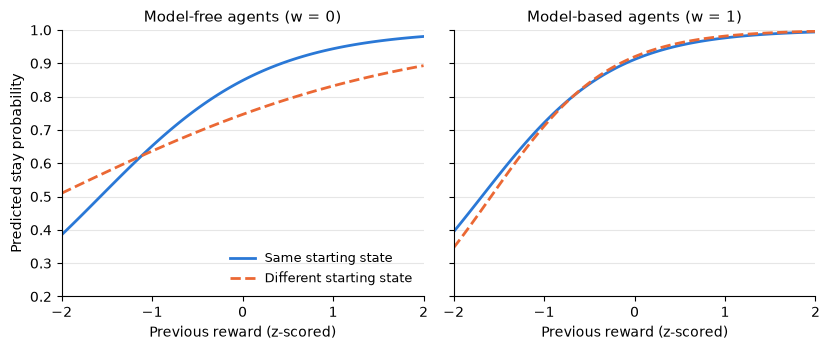

In [9]:
def plot_stay(glms, titles):
    fig, axes = plt.subplots(1, len(glms), figsize=(4.2 * len(glms), 3.6), sharey=True)
    for ax, (name, result) in zip(np.atleast_1d(axes), glms.items()):
        z, curves = predicted_stay(result)
        ax.plot(z, curves[1.0], color=COLOR_SAME, linewidth=2, label="Same starting state")
        ax.plot(z, curves[-1.0], color=COLOR_DIFF, linewidth=2, linestyle="--",
                label="Different starting state")
        ax.set_title(titles[name], fontsize=11)
        ax.set_xlabel("Previous reward (z-scored)")
        ax.set_xlim(-2, 2)
        ax.set_xticks([-2, -1, 0, 1, 2])
        ax.set_ylim(0.2, 1.0)
        ax.grid(axis="y", color="#e6e6e6", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
    np.atleast_1d(axes)[0].set_ylabel("Predicted stay probability")
    np.atleast_1d(axes)[0].legend(frameon=False, fontsize=9, loc="lower right")
    fig.tight_layout()
    return fig


fig = plot_stay(
    {k: glms[k] for k in ["model-free", "model-based"]},
    {"model-free": "Model-free agents (w = 0)", "model-based": "Model-based agents (w = 1)"},
)
plt.show()

For model-free agents, the previous reward has a stronger effect on staying when the starting state repeats: the two lines have different slopes, which shows up as a positive `prevpoints_x_same` coefficient.
There is still some effect of reward when the starting state changes, because rewards drift slowly: a planet that just paid out well has often paid out well before, including on earlier visits from the other starting state.
For model-based agents, the previous reward increases staying equally in both conditions: the two lines overlap and the interaction is close to zero.
This is the pattern of the generalised model predictions in Figure 4a of Smid et al. (2022).

## Parameter recovery

Before fitting the model to real participants, we should check that its parameters can be recovered from data of this size (Wilson & Collins, 2019).
We simulate a new set of agents whose parameters are drawn at random, fit the model to their choices, and compare the estimated parameters with the ones that generated the data.

In [10]:
n_recovery = 40
rng = np.random.default_rng(1)
true_parameters = pd.DataFrame(
    {
        "inv_temperature": rng.uniform(0.2, 3, n_recovery),
        "learning_rate": rng.uniform(0.1, 0.9, n_recovery),
        "eligibility_trace": rng.uniform(0.1, 0.9, n_recovery),
        "mb_weight": rng.uniform(0, 1, n_recovery),
        "choice_stickiness": rng.uniform(-1, 1, n_recovery),
        "response_stickiness": rng.uniform(-1, 1, n_recovery),
    }
)

recovery_environment = make_environment(n_participants=n_recovery, seed=7)
np.random.seed(7)
simulator = Simulator(
    wrapper=HybridMBMF(data=recovery_environment[recovery_environment.ppt == 0], q_init=4.5, generate=True),
    data=recovery_environment.groupby("ppt"),
    parameters=true_parameters,
)
simulator.run()
simulated = simulator.export()

To fit the model, the data must contain the observed action, the planet reached, and the reward received on each trial.
The model predicts the probability of choosing action 1, so the `observed` column is the chosen action.

In [11]:
recovery_data = recovery_environment.copy()
recovery_data[["action", "s2", "reward", "position"]] = simulated[
    ["action", "s2", "reward", "position"]
].to_numpy().astype(int)
recovery_data["observed"] = recovery_data["action"]

fitting_model = HybridMBMF(
    data=recovery_data[recovery_data.ppt == 0],
    q_init=4.5,
)

We use [`FminBound`](#cpm.optimisation.FminBound) (L-BFGS-B) to find the maximum a posteriori estimates, with the priors defined in `HybridMBMF`, and a few random starting points per participant.

In [12]:
fit = FminBound(
    model=fitting_model,
    data=recovery_data.groupby("ppt"),
    minimisation=minimise.LogLikelihood.bernoulli,
    prior=True,
    number_of_starts=3,
    parallel=True,
    approx_grad=True,
)
fit.optimise()

In [13]:
parameter_names = fitting_model.parameters.free()
estimated = pd.DataFrame(
    [{name: float(ppt[name]) for name in parameter_names} for ppt in fit.parameters]
)
estimated.describe().round(3)

,inv_temperature,learning_rate,eligibility_trace,mb_weight,choice_stickiness,response_stickiness
count,40.000,40.000,40.000,40.000,40.000,40.000
mean,1.997,0.525,0.480,0.449,0.042,0.117
std,1.152,0.227,0.136,0.181,0.555,0.594
min,0.302,0.114,0.160,0.126,-0.999,-1.109
25%,1.049,0.309,0.393,0.295,-0.428,-0.320
50%,1.685,0.554,0.465,0.451,0.146,0.243
75%,2.989,0.697,0.557,0.593,0.330,0.582
max,4.068,0.952,0.819,0.887,1.536,1.090


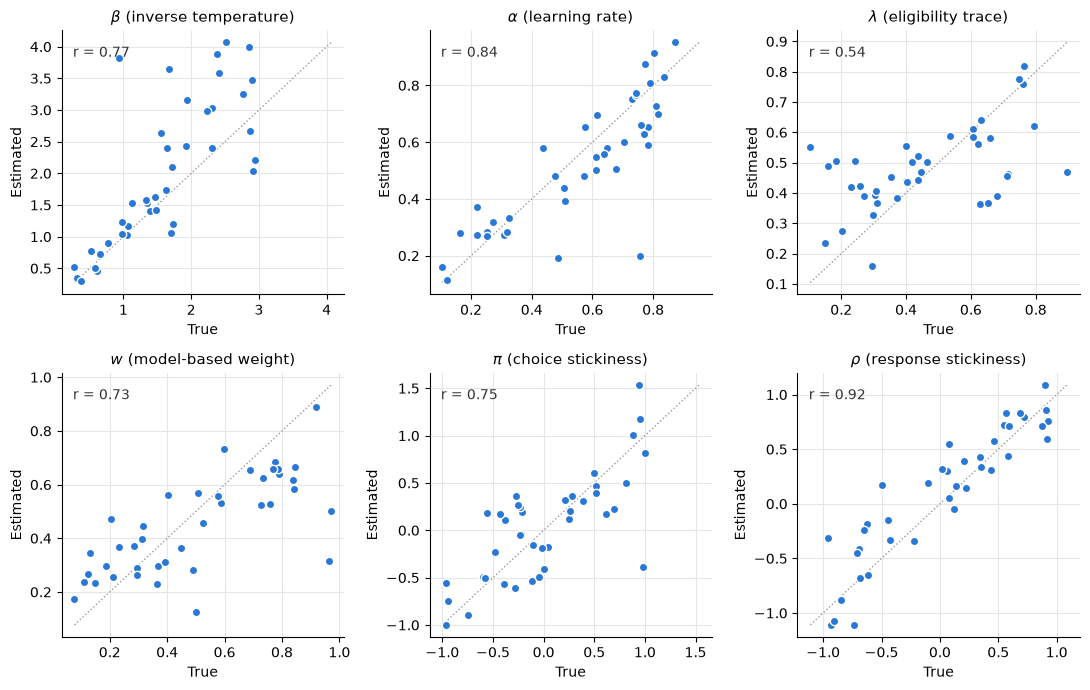

In [14]:
labels = {
    "inv_temperature": r"$\beta$ (inverse temperature)",
    "learning_rate": r"$\alpha$ (learning rate)",
    "eligibility_trace": r"$\lambda$ (eligibility trace)",
    "mb_weight": r"$w$ (model-based weight)",
    "choice_stickiness": r"$\pi$ (choice stickiness)",
    "response_stickiness": r"$\rho$ (response stickiness)",
}

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, name in zip(axes.flatten(), parameter_names):
    x, y = true_parameters[name], estimated[name]
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color="#999999", linewidth=1, linestyle=":")
    ax.scatter(x, y, s=36, color=COLOR_SAME, edgecolor="white", linewidth=1, zorder=3)
    ax.set_title(labels[name], fontsize=11)
    ax.text(0.04, 0.94, f"r = {np.corrcoef(x, y)[0, 1]:.2f}", transform=ax.transAxes,
            va="top", fontsize=10, color="#333333")
    ax.set_xlabel("True")
    ax.set_ylabel("Estimated")
    ax.grid(color="#e6e6e6", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

Points close to the dotted identity line mean the parameter is well recovered.
With 140 trials per participant, response stickiness and the learning rate are recovered well, while the eligibility trace is recovered poorly.
The estimates of the model-based weight are pulled towards 0.5, the mean of its prior: agents with a very high or very low $w$ are estimated as more mixed than they are.
The inverse temperature is recovered well at low values but becomes noisier at high values, where choices are nearly deterministic.
It is worth running a recovery like this with your own task length and parameter ranges before interpreting fitted parameters.

## Replicating Smid et al. (2022): adult participants

Now that we know what the model predicts and how well its parameters can be recovered, we turn to the adult data of Smid et al. (2022), which ship with cpm and are loaded with [`load_two_step_data`](#cpm.datasets.load_two_step_data).
The data were originally published by the authors in the [Model-based_Model-free_Developmental](https://github.com/ClaireSmid/Model-based_Model-free_Developmental) repository on GitHub.
We will replicate two analyses: the stay probabilities of Figure 4b, and the distributions of the fitted model parameters.

### Loading the data

The data have one row per trial and participant (`ppt`), with the original coding of the task:

- `s1`, `s2`: the starting state and the planet reached (1 or 2; 0 marks a missed trial),
- `choice`: the chosen spaceship, numbered 1 to 4 across both starting states (-1 marks a missed trial),
- `stimuli_left`, `stimuli_right`: which spaceships were displayed on the left and right,
- `points`: the reward, scaled between 0 and 1,
- `timeout_1`, `timeout_2`: whether the participant failed to respond in time at either stage.

The file also contains the stake of each trial, the rewards both planets would have paid out (`rews_1`, `rews_2`), response times, and the running score, which we do not need here.
We convert these into the 0-indexed columns that `HybridMBMF` expects.
The chosen spaceship is converted to an action within its starting state (spaceships 1 and 3 are action 0, spaceships 2 and 4 are action 1), and the rewards are rescaled to the original 0 to 9 points.
We keep all trials for now and mark the missed and timed-out ones as invalid, because the stay analysis needs to know what happened on the previous trial.

In [15]:
from cpm.datasets import load_two_step_data


def load_adult_data():
    """Load the adult two-step data of Smid et al. (2022) and convert it to 0-indexed model inputs."""
    raw = load_two_step_data()
    timed_out = (raw["timeout_1"] == 1) | (raw["timeout_2"] == 1)
    return pd.DataFrame(
        {
            "ppt": raw["ppt"],
            "trial": raw["trial"],
            "s1": raw["s1"] - 1,
            "s2": raw["s2"] - 1,
            "action": raw["choice"] - (raw["s1"] == 2) * 2 - 1,
            ## spaceships 2 and 4 on the left mean that action 1 is displayed first
            "stimuli_first": (raw["stimuli_left"] % 2 == 0).astype(int),
            "reward": (raw["points"] * 9).round(),
            "valid": (raw["s1"] > 0) & (raw["s2"] > 0) & ~timed_out,
        }
    )


adults = load_adult_data()
print(f"{adults.ppt.nunique()} participants, {adults.valid.sum()} valid trials out of {len(adults)}")
adults.head()

24 participants, 3267 valid trials out of 3360


,ppt,trial,s1,s2,action,stimuli_first,reward,valid
0,101,0,1,0,1,0,8.0,True
1,101,1,1,0,1,0,9.0,True
2,101,2,0,0,1,1,8.0,True
3,101,3,0,0,1,0,8.0,True
4,101,4,1,1,0,0,2.0,True


### Stay probabilities (Figure 4b)

We compute the stay variables as before, but only keep trials where both the current and the previous trial are valid.

In [16]:
def empirical_stay_variables(data):
    """Stay variables for trials where both the current and the previous trial are valid."""
    data = data.copy()
    previous = data.groupby("ppt")[["s1", "s2", "reward", "valid"]].shift(1)
    data["stay"] = (data["s2"] == previous["s2"]).astype(float)
    data["same"] = np.where(data["s1"] == previous["s1"], 1.0, -1.0)
    data["prevpoints"] = previous["reward"]
    keep = data["valid"] & previous["valid"].eq(True)
    return data[keep].reset_index(drop=True)


adult_stay = empirical_stay_variables(adults)
adult_glm = fit_stay_glm(adult_stay)
adult_glm.summary2().tables[1].round(3)

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
const,0.712,0.043,16.725,0.000,0.629,0.796
prevpoints_z,1.040,0.045,22.951,0.000,0.951,1.128
same,0.058,0.043,1.371,0.170,-0.025,0.142
prevpoints_x_same,0.095,0.045,2.100,0.036,0.006,0.184


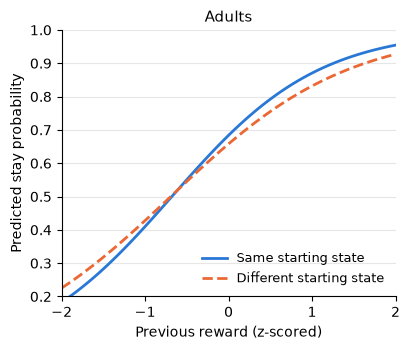

In [17]:
fig = plot_stay({"adults": adult_glm}, {"adults": "Adults"})
plt.show()

As in the simulations, a positive `prevpoints_z` coefficient means that rewards increase staying regardless of the starting state (a model-based signature), and a positive `prevpoints_x_same` coefficient means that they increase staying more when the starting state repeats (a model-free signature).
Smid et al. (2022) fitted a mixed-effects model with a random intercept per participant (`glmer(stay ~ prevpoints * same + (1|subnr))`), so the coefficients here, from a plain logistic regression, will differ somewhat from the published ones; the predicted curves should show the same pattern as Figure 4b.

In the adults, the previous reward strongly increases staying in both conditions, and the extra effect when the starting state repeats is small: behaviour looks mostly model-based, with a small model-free component.

### Fitting the model to each participant

We fit `HybridMBMF` to the valid trials of each participant, using the same settings as in the parameter recovery above.
Missed and timed-out trials are removed, so the model carries its values over them unchanged.
Because the rewards are on the 0 to 9 scale, we initialise the values at 4.5, as in the original MATLAB code.

In [18]:
adult_data = adults[adults.valid].copy()
adult_data["position"] = adult_data["stimuli_first"] ^ adult_data["action"]
adult_data["observed"] = adult_data["action"]

adult_model = HybridMBMF(data=adult_data[adult_data.ppt == adult_data.ppt.iloc[0]], q_init=4.5)
adult_fit = FminBound(
    model=adult_model,
    data=adult_data.groupby("ppt"),
    minimisation=minimise.LogLikelihood.bernoulli,
    prior=True,
    number_of_starts=5,
    parallel=True,
    approx_grad=True,
)
adult_fit.optimise()

adult_parameters = pd.DataFrame(
    [{name: float(ppt[name]) for name in parameter_names} for ppt in adult_fit.parameters]
)
adult_parameters.describe().round(3)

,inv_temperature,learning_rate,eligibility_trace,mb_weight,choice_stickiness,response_stickiness
count,24.000,24.000,24.000,24.000,24.000,24.000
mean,0.469,0.789,0.508,0.759,0.054,-0.225
std,0.233,0.201,0.062,0.168,0.738,0.536
min,0.140,0.150,0.332,0.461,-1.097,-1.239
25%,0.326,0.712,0.492,0.608,-0.490,-0.704
50%,0.412,0.841,0.504,0.814,0.032,-0.018
75%,0.577,0.937,0.551,0.868,0.702,0.142
max,1.059,1.000,0.596,1.000,1.438,0.824


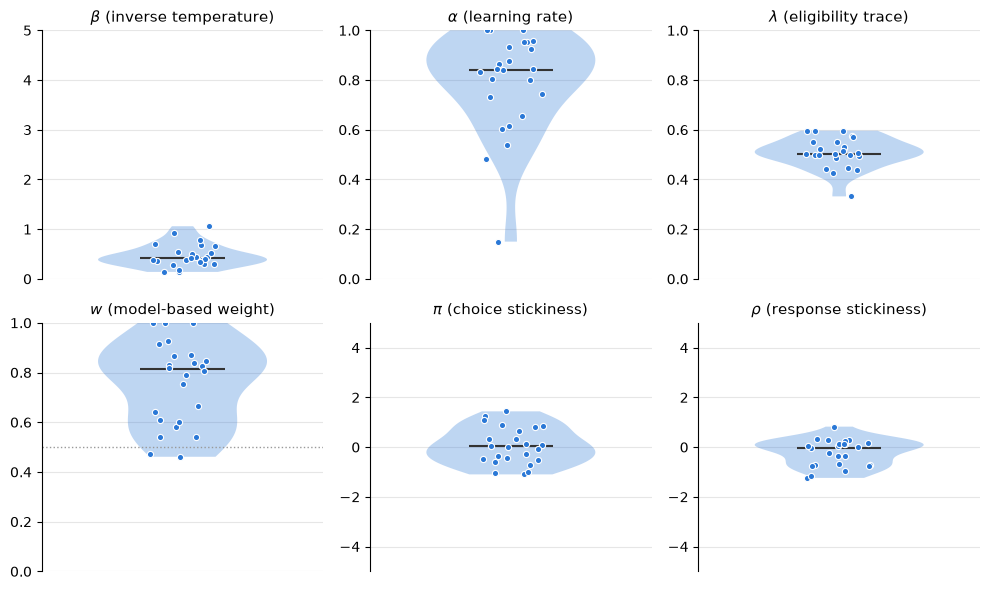

In [19]:
limits = {
    "inv_temperature": (0, 5),
    "learning_rate": (0, 1),
    "eligibility_trace": (0, 1),
    "mb_weight": (0, 1),
    "choice_stickiness": (-5, 5),
    "response_stickiness": (-5, 5),
}

rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for ax, name in zip(axes.flatten(), parameter_names):
    values = adult_parameters[name].to_numpy()
    violin = ax.violinplot(values, positions=[0], widths=0.6, showmedians=True, showextrema=False)
    for body in violin["bodies"]:
        body.set_facecolor(COLOR_SAME)
        body.set_alpha(0.3)
    violin["cmedians"].set_color("#333333")
    ax.scatter(rng.uniform(-0.12, 0.12, len(values)), values, s=20, color=COLOR_SAME,
               edgecolor="white", linewidth=0.8, zorder=3)
    if name == "mb_weight":
        ax.axhline(0.5, color="#999999", linestyle=":", linewidth=1)
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(*limits[name])
    ax.set_xticks([])
    ax.set_title(labels[name], fontsize=11)
    ax.grid(axis="y", color="#e6e6e6", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "bottom"]].set_visible(False)
fig.tight_layout()
plt.show()

Each point is one participant, and the violins show the distribution of the estimates, with the median as a horizontal line.
The dotted line in the model-based weight panel marks an equal mix of model-based and model-free control.

In line with the stay analysis, most adults rely more on model-based than on model-free control (median $w$ around 0.8).
Keep the parameter recovery in mind when reading these distributions: the eligibility trace estimates cluster around 0.5, the mean of its prior, which is what we would expect for a parameter that the data constrain only weakly.

## Summary and next steps

You simulated model-free and model-based agents on the two-step task, showed how their stay behaviour differs, checked which parameters of [`HybridMBMF`](#cpm.applications.reinforcement_learning.HybridMBMF) can be recovered with 140 trials, and replicated the stay analysis and the parameter distributions of the adults of Smid et al. (2022).

- The model is built from [`SARSATrace`](#cpm.models.learning.SARSATrace); to build variants of your own, see [Tutorial 1](../tutorials/first-model.ipynb).
- The weakly constrained eligibility trace is a good candidate for hierarchical estimation: see [Tutorial 4](../tutorials/hierarchical-empirical-bayes.ipynb).
- To fit many participants faster, see the how-to guide on [parallel fitting](../how-to/parallelise-fitting.md).

## References

Kool, W., Cushman, F. A., & Gershman, S. J. (2016). When does model-based control pay off? *PLoS Computational Biology*, 12(8), e1005090. https://doi.org/10.1371/journal.pcbi.1005090

Smid et al. (2022). Computational and behavioral correlates of developmental changes in model-based/model-free decision-making. *Developmental Science*, e13380.

Wilson, R. C., & Collins, A. G. E. (2019). Ten simple rules for the computational modeling of behavioral data. *eLife*, 8, e49547. https://doi.org/10.7554/eLife.49547